# Sprites, animation, camera & tile maps
* in lesson 27 we drew everything by hand, every single frame - `pygame.draw.rect(...)`, `pygame.draw.circle(...)`, over and over. that works fine for a couple of shapes, but a real game might have dozens of moving things (the player, enemies, coins, bullets, ...) and manually redrawing/repositioning each one gets messy fast
* pygame gives us a much cleaner pattern for this: `pygame.sprite.Sprite` (a base class we subclass, recap OOP/inheritance from lesson 07) and `pygame.sprite.Group` (a container that updates and draws a whole bunch of sprites with one line each)
* in this lesson we build up: sprites & groups -> simple frame animation -> velocity/gravity movement -> a scrolling camera -> tile-based maps. this is exactly the toolbox the upcoming RPG lessons (31/32) are built out of, so make sure this one really clicks

## quick setup recap
* same headless-notebook trick as lesson 27: `SDL_VIDEODRIVER`/`SDL_AUDIODRIVER` set to `"dummy"` BEFORE importing pygame, and our `show_surface()` helper to view a Surface inline. nothing new here, just getting our screen ready

In [1]:
import os

# same trick as lesson 27 - these two MUST run before "import pygame" at all
os.environ["SDL_VIDEODRIVER"] = "dummy"  # render off-screen, no real window needed in this notebook
os.environ["SDL_AUDIODRIVER"] = "dummy"  # no real sound device needed either

import pygame
import numpy as np
import matplotlib.pyplot as plt

pygame.init()  # start up pygame's subsystems, same as lesson 27


def show_surface(surface, title=None, figsize=(4, 3)):
    """Render a pygame Surface inline in the notebook (recap lesson 27)."""
    # pygame stores pixels as (width, height, channels), matplotlib wants (height, width, channels) - swap axes
    pixel_array = pygame.surfarray.array3d(surface).swapaxes(0, 1)
    plt.figure(figsize=figsize)
    plt.imshow(pixel_array)
    plt.axis("off")  # a game screenshot doesnt need x/y ticks
    if title:
        plt.title(title)
    plt.show()


SCREEN_WIDTH, SCREEN_HEIGHT = 320, 240  # our "window" size, same as lesson 27
screen = pygame.display.set_mode((SCREEN_WIDTH, SCREEN_HEIGHT))  # our off-screen surface, everything draws onto this
print("pygame ready, screen size:", screen.get_size())

pygame 2.6.1 (SDL 2.28.4, Python 3.11.15)
Hello from the pygame community. https://www.pygame.org/contribute.html


pygame ready, screen size: (320, 240)


## `pygame.sprite.Sprite` - a reusable base class for "things in our game"
* every sprite class we write should inherit from `pygame.sprite.Sprite` (recap inheritance from lesson 07 - `class MySprite(pygame.sprite.Sprite):`)
* two attributes are mandatory for every sprite: `self.image` (its own little `Surface` - what it LOOKS like) and `self.rect` (a `pygame.Rect` - WHERE it is and how big it is, recap `Rect` from lesson 27's collision section)
* `update()` is a method NAME pygame's `Group` looks for and calls automatically every frame - we override it to describe what this sprite does each frame (move, animate, whatever). its just a convention, nothing magic, but sticking to it is what makes `Group.update()` work for free
* always call `super().__init__()` first inside your own `__init__` - it wires up bookkeeping the base `Sprite` class needs (like knowing which Groups it belongs to)

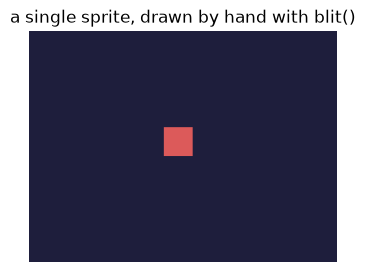

In [2]:
class ColorBlockSprite(pygame.sprite.Sprite):
    """The simplest possible custom sprite - just a flat colored square that CAN move (but doesn't by default)."""

    def __init__(self, x, y, size, color):
        super().__init__()  # always call the parent Sprite's __init__ first, it needs to run
        # every sprite needs its own "image" - here just a brand new Surface, filled with one flat color
        self.image = pygame.Surface((size, size))
        self.image.fill(color)
        # every sprite also needs a "rect" - position AND size combined, get_rect() builds one that matches self.image
        self.rect = self.image.get_rect()
        self.rect.x = x  # then we move that rect to wherever we actually want to start
        self.rect.y = y

    def update(self):
        # Group.update() will call this every frame - this basic sprite just doesn't do anything on its own yet
        pass  # subclasses further down will override this with real behaviour (animating, moving, ...)


# lets make one on its own first, just to see it drawn - no Group needed for a single sprite
lonely_sprite = ColorBlockSprite(140, 100, 30, (220, 90, 90))
screen.fill((30, 30, 60))
screen.blit(lonely_sprite.image, lonely_sprite.rect)  # blit() happily accepts a Rect directly as the position
show_surface(screen, title="a single sprite, drawn by hand with blit()")

## `pygame.sprite.Group` - managing many sprites at once
* a `Group` is basically a smart collection of sprites - `group.add(sprite)` puts one in, and it supports `len(group)`, `for sprite in group:`, etc, just like a normal python container
* `group.update()` calls `.update()` on EVERY sprite inside it - one line instead of a manual for-loop over all our sprites
* `group.draw(surface)` draws EVERY sprite's `.image` at its `.rect` position onto the given surface - again, one line for however many sprites we have
* this is the real payoff of the Sprite/Group pattern: our game loop stays exactly 2 lines (`group.update()` + `group.draw(screen)`) no matter if we have 3 sprites or 300

sprites currently in the group: 3


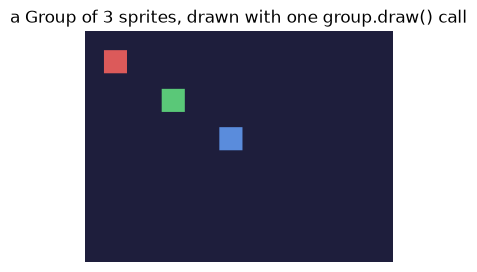

In [3]:
sprite_group = pygame.sprite.Group()  # start with an empty group

# add a few sprites with different positions and colors
sprite_group.add(ColorBlockSprite(20, 20, 24, (220, 90, 90)))
sprite_group.add(ColorBlockSprite(80, 60, 24, (90, 200, 120)))
sprite_group.add(ColorBlockSprite(140, 100, 24, (90, 140, 220)))

print("sprites currently in the group:", len(sprite_group))  # Group supports len() out of the box

for frame_number in range(5):  # a few frames, just to prove update() really does get called on every sprite
    sprite_group.update()  # calls ColorBlockSprite.update() on all 3 sprites - currently a no-op, but wired up

screen.fill((30, 30, 60))
sprite_group.draw(screen)  # draws all 3 sprites in one call, no manual loop needed on our side
show_surface(screen, title="a Group of 3 sprites, drawn with one group.draw() call")

## simple frame animation
* real games rarely draw a static image for a moving character - they cycle through a few slightly different-looking "frames" to fake movement (a classic 2-frame or 4-frame "walk cycle" is a very old, very common trick, going all the way back to the earliest video games)
* since this course has no image asset files, we hand-build our "frames" as tiny `pygame.Surface`s with `pygame.draw` shapes on them - completely fine for prototyping, and it teaches the exact same mechanism a real sprite-sheet-based animation uses
* the trick: store our frames in a list (`self.frames`), keep track of `self.frame_index`, and swap `self.image = self.frames[self.frame_index]` every few ticks inside `update()` - not every single frame, or the animation would flicker way too fast to look like walking

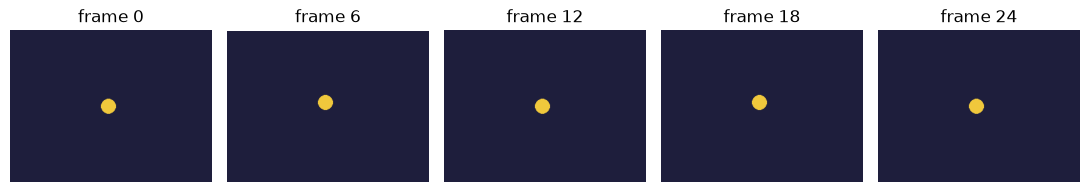

In [4]:
class WalkingBlobSprite(pygame.sprite.Sprite):
    """A sprite that cycles through 2 hand-drawn poses to fake a little walk animation."""

    def __init__(self, x, y):
        super().__init__()
        self.frames = self._build_frames()  # build our list of animation frames once, up front
        self.frame_index = 0  # which frame in self.frames we are currently showing
        self.ticks_since_last_frame = 0  # counts frames passed, so we don't flip pose every single frame
        self.image = self.frames[self.frame_index]  # start out showing frame 0
        self.rect = self.image.get_rect()
        self.rect.x = x
        self.rect.y = y

    def _build_frames(self):
        # SRCALPHA lets the corners of the little Surface stay transparent instead of an ugly black box
        frame_a = pygame.Surface((32, 32), pygame.SRCALPHA)
        pygame.draw.circle(frame_a, (240, 200, 60), (16, 20), 12)  # body drawn lower - "legs together" pose
        frame_b = pygame.Surface((32, 32), pygame.SRCALPHA)
        pygame.draw.circle(frame_b, (240, 200, 60), (16, 14), 12)  # body drawn higher - "mid-step" pose
        return [frame_a, frame_b]  # a 2-frame walk cycle, just like an old sprite sheet would give us

    def update(self):
        self.ticks_since_last_frame += 1  # one more frame has passed
        if self.ticks_since_last_frame >= 6:  # only advance the animation every 6 frames - controls its SPEED
            self.ticks_since_last_frame = 0
            self.frame_index = (self.frame_index + 1) % len(self.frames)  # wrap back to 0 after the last frame
            self.image = self.frames[self.frame_index]  # actually swap which pose is displayed


blob = WalkingBlobSprite(140, 100)
animation_group = pygame.sprite.Group(blob)  # Group(...) also happily accepts sprites straight in the constructor

animation_snapshots = []
for frame_number in range(30):
    animation_group.update()
    screen.fill((30, 30, 60))
    animation_group.draw(screen)
    if frame_number % 6 == 0:  # grab a snapshot right as the pose is about to flip, so we can SEE it changing
        animation_snapshots.append((frame_number, pygame.surfarray.array3d(screen).swapaxes(0, 1).copy()))

fig, axes = plt.subplots(1, len(animation_snapshots), figsize=(2.2 * len(animation_snapshots), 2.2))
for ax, (frame_number, pixels) in zip(axes, animation_snapshots):
    ax.imshow(pixels)
    ax.set_title(f"frame {frame_number}")
    ax.axis("off")
plt.tight_layout()
plt.show()

## movement with velocity + a bit of "physics-lite" (gravity & jumping)
* a lot of games (platformers especially) fake gravity with just a couple of lines: every frame, add a small constant amount to the vertical velocity (`velocity_y += GRAVITY`) - this is a very simplified stand-in for real physics, but its more than enough for a fun-feeling jump arc
* jumping is just setting `velocity_y` to a (negative, since up is negative in pygame!) value once, then letting gravity pull it back down naturally over the following frames
* "landing" means: once we'd go below the ground level, snap back onto the ground and reset `velocity_y` to `0` - otherwise we'd sink through the floor forever

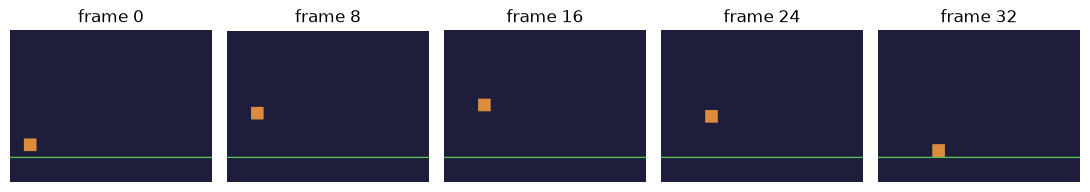

In [5]:
class JumpingSprite(pygame.sprite.Sprite):
    """Walks steadily to the right while gravity pulls it down and a jump can kick it upward."""

    GRAVITY = 0.6  # how much velocity_y increases every frame - bigger number = falls faster
    GROUND_Y = 180  # the rect.y we treat as "standing on the ground"
    JUMP_STRENGTH = -10.0  # negative because y grows DOWNWARDS in pygame - "up" is negative velocity

    def __init__(self, x, y):
        super().__init__()
        self.image = pygame.Surface((20, 20))
        self.image.fill((220, 140, 60))
        self.rect = self.image.get_rect()
        self.rect.x = x
        self.rect.y = y
        self.velocity_x = 2.0  # constant horizontal speed - just keeps walking right
        self.velocity_y = 0.0  # vertical speed, changes every frame due to gravity/jumping

    def jump(self):
        if self.rect.y >= self.GROUND_Y:  # only allow jumping while actually standing on the ground
            self.velocity_y = self.JUMP_STRENGTH  # give it one strong upward kick

    def update(self):
        self.velocity_y += self.GRAVITY  # gravity pulls us back down a little more, every single frame
        self.rect.x += int(self.velocity_x)
        self.rect.y += int(self.velocity_y)
        if self.rect.y > self.GROUND_Y:  # did we fall past the ground?
            self.rect.y = self.GROUND_Y  # snap exactly back onto it
            self.velocity_y = 0.0  # landing kills all vertical speed until the next jump


jumper = JumpingSprite(20, JumpingSprite.GROUND_Y)
jump_group = pygame.sprite.Group(jumper)

jump_snapshots = []
TOTAL_JUMP_FRAMES = 40
for frame_number in range(TOTAL_JUMP_FRAMES):
    if frame_number == 0:
        jumper.jump()  # trigger the jump right at the very start, so we get to see the whole arc unfold
    jump_group.update()
    screen.fill((30, 30, 60))
    # draw a "ground" line just for visual reference, purely cosmetic
    pygame.draw.line(screen, (90, 200, 90), (0, JumpingSprite.GROUND_Y + 20), (SCREEN_WIDTH, JumpingSprite.GROUND_Y + 20), 2)
    jump_group.draw(screen)
    if frame_number % 8 == 0:
        jump_snapshots.append((frame_number, pygame.surfarray.array3d(screen).swapaxes(0, 1).copy()))

fig, axes = plt.subplots(1, len(jump_snapshots), figsize=(2.2 * len(jump_snapshots), 2.2))
for ax, (frame_number, pixels) in zip(axes, jump_snapshots):
    ax.imshow(pixels)
    ax.set_title(f"frame {frame_number}")
    ax.axis("off")
plt.tight_layout()
plt.show()

## a scrolling camera
* every game so far fit entirely inside our tiny 320x240 screen - but real game WORLDS are usually much bigger than the screen that shows them. the trick is a **camera**: we keep a `camera_offset_x` (and often `_y` too) and draw everything at `sprite.rect.x - camera_offset_x` instead of its raw world position
* as the offset grows, everything appears to shift LEFT on screen even though nothing in the world actually moved - thats the whole illusion of "the camera scrolling"
* we usually want the camera to roughly follow the player, but CLAMPED so it never scrolls past the edges of the world (otherwise you'd see empty space beyond the map) - `max(0, ...)` stops it going below the left edge, `min(..., world_width - screen_width)` stops it going past the right edge

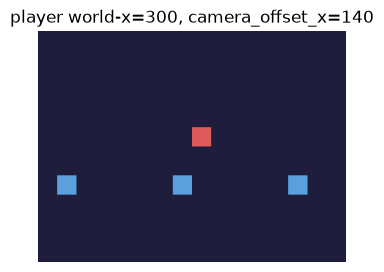

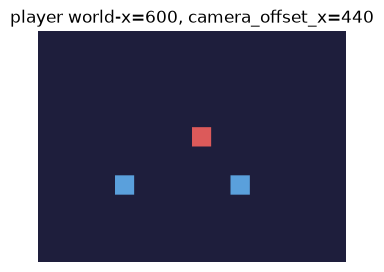

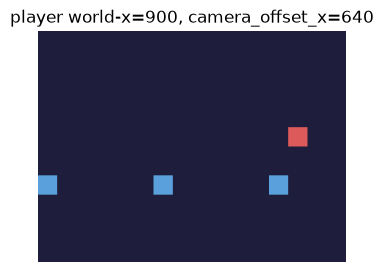

In [6]:
WORLD_WIDTH = 960  # our world is 3x wider than the 320px screen - way more than fits on screen at once

# scatter a few "world objects" across the WHOLE wide world, most of them off-screen from the very start
world_sprites = pygame.sprite.Group()
for world_x in range(40, WORLD_WIDTH, 120):  # one sprite every 120 pixels along the entire world
    world_sprites.add(ColorBlockSprite(world_x, 150, 20, (90, 160, 220)))

player = ColorBlockSprite(0, 100, 20, (220, 90, 90))  # our "player", starting at the very left edge of the world


def draw_world(camera_offset_x, title):
    screen.fill((30, 30, 60))
    for sprite in world_sprites:  # Group supports "for sprite in group", just like a normal python container
        # this line IS the whole scrolling trick: subtract the camera offset from every world x position
        screen.blit(sprite.image, (sprite.rect.x - camera_offset_x, sprite.rect.y))
    screen.blit(player.image, (player.rect.x - camera_offset_x, player.rect.y))  # player drawn camera-relative too
    show_surface(screen, title=title)


# simulate the player walking to the right across the wide world, in 3 big steps, camera following along
for step in range(3):
    player.rect.x += 300  # move the player a big chunk to the right (like many frames of walking happened at once)
    camera_offset_x = player.rect.x - SCREEN_WIDTH // 2  # try to keep the player roughly centered on screen
    camera_offset_x = max(0, camera_offset_x)  # never scroll past the world's LEFT edge (would show empty space)
    camera_offset_x = min(camera_offset_x, WORLD_WIDTH - SCREEN_WIDTH)  # never scroll past the RIGHT edge either
    draw_world(camera_offset_x, title=f"player world-x={player.rect.x}, camera_offset_x={camera_offset_x}")

## tile-based maps
* another extremely common 2D game technique: instead of drawing a big custom background image, split the world into a grid of equally-sized **tiles** and describe the map as a simple 2D list of tile IDs (plain integers)
* a small dict then maps each tile ID to what it actually means/looks like (here just a color: `0` = grass, `1` = wall, `2` = water) - a real game would map each ID to a little image instead, but the DATA SHAPE is identical
* rendering is just a nested loop: for every `(row, column)` in the grid, draw one colored rect at `(column * tile_size, row * tile_size)` - this exact pattern (grid of ids + id-to-appearance lookup + nested-loop renderer) is precisely what the upcoming RPG lessons build their game world out of

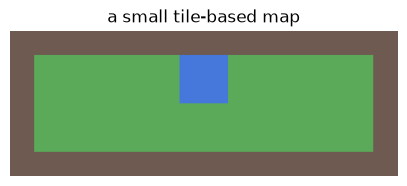

In [7]:
TILE_SIZE = 20  # each tile is 20x20 pixels

# our map: a 2D list of ints, one row per list - 0 = grass, 1 = wall, 2 = water
tile_map = [
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 0, 0, 0, 0, 0, 0, 2, 2, 0, 0, 0, 0, 0, 0, 1],
    [1, 0, 0, 0, 0, 0, 0, 2, 2, 0, 0, 0, 0, 0, 0, 1],
    [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
    [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
]

TILE_COLORS = {
    0: (90, 170, 90),   # 0 = grass
    1: (110, 90, 80),   # 1 = wall
    2: (70, 120, 220),  # 2 = water
}


def draw_tile_map(surface, tile_map, tile_colors):
    for row_index, row in enumerate(tile_map):  # enumerate gives us the row index alongside each row (lesson 03!)
        for column_index, tile_id in enumerate(row):  # same trick for the column index within the row
            color = tile_colors[tile_id]  # look up what this tile id actually means
            tile_rect = (column_index * TILE_SIZE, row_index * TILE_SIZE, TILE_SIZE, TILE_SIZE)  # (x, y, w, h)
            pygame.draw.rect(surface, color, tile_rect)


map_width_px = len(tile_map[0]) * TILE_SIZE  # number of columns * tile size
map_height_px = len(tile_map) * TILE_SIZE  # number of rows * tile size
map_surface = pygame.Surface((map_width_px, map_height_px))  # a dedicated surface sized exactly to fit our map
draw_tile_map(map_surface, tile_map, TILE_COLORS)
show_surface(map_surface, title="a small tile-based map", figsize=(5, 2.5))

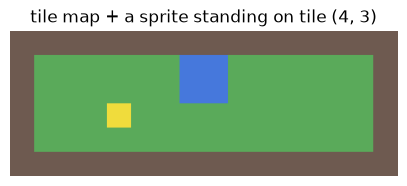

In [8]:
# now lets place a SPRITE at a specific tile position - tying sprites and tile maps together
hero_tile_column, hero_tile_row = 4, 3  # "grid coordinates" - which column/row of the map, not raw pixels
hero_sprite = ColorBlockSprite(hero_tile_column * TILE_SIZE, hero_tile_row * TILE_SIZE, TILE_SIZE, (240, 220, 60))

map_surface_with_hero = map_surface.copy()  # copy so we don't permanently draw over our clean map surface
map_surface_with_hero.blit(hero_sprite.image, hero_sprite.rect)  # blit() again accepts the rect directly
show_surface(map_surface_with_hero, title="tile map + a sprite standing on tile (4, 3)", figsize=(5, 2.5))

## quick comparison to other languages
* pygame's `Sprite`/`Group` pattern (a base class you subclass, then batched `update()` + `draw()` over the whole collection) is conceptually similar to Unity's `MonoBehaviour` components or Godot's `Node`/`Node2D` scene tree - but both of those are full EDITORS with a visual scene graph you drag-and-drop things into, while pygame's version is just plain python objects you manage entirely yourself in code
* tile-based maps are an extremely common 2D game technique across basically every engine and era - from the NES/SNES days all the way through to modern indie games. the free tool **Tiled** (tiled.org) is a hugely popular, language-agnostic map EDITOR that exports the exact same "2D grid of tile ids" data shape we hand-built here, just through a nice visual UI instead of a python list literal - and pygame, Godot, Unity, or basically anything can load a Tiled export
* JavaScript's **Phaser** framework has near-identical Sprite/Group and tilemap concepts built in natively, so this whole lesson's mental model transfers pretty directly if you ever pick it up

## Exercises
1. create a `Sprite` subclass that moves DIAGONALLY (both x and y velocity) and bounces off ALL 4 edges of a 320x240 screen (reverse the matching velocity component whenever it would go off an edge) - run it for enough frames to see at least one bounce happen, and show a few snapshots
2. add a 3RD animation frame to the walk-cycle example above (a slightly different pose again) and show it cycling through all 3 frames over time
3. extend the scrolling camera example so it also clamps VERTICALLY, not just horizontally (imagine a world that is taller than the screen too)
4. add a new tile type (`3` = "sand") to the tilemap color dict, place a few sand tiles into a copy of the example map, and re-render it to show the sand showing up

In [9]:
# TODO: solve exercise 1 here (a Sprite subclass bouncing off all 4 screen edges)


# TODO: solve exercise 2 here (add a 3rd animation frame, show it cycling)


# TODO: solve exercise 3 here (camera example, clamped both horizontally and vertically)


# TODO: solve exercise 4 here (add a "sand" tile type, place a few, re-render the map)

### sample solutions
* try the exercises above yourself first, only look here if you are stuck or want to compare your approach

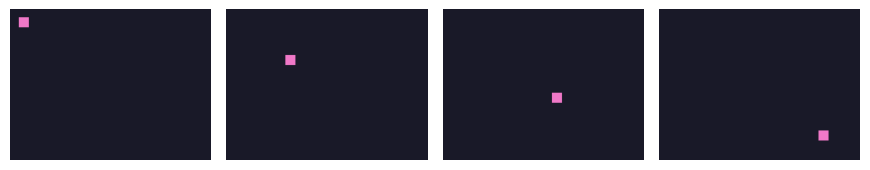

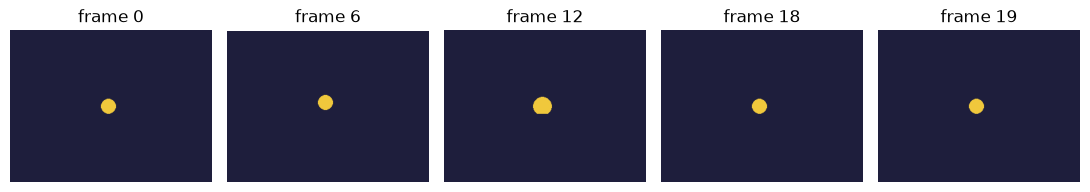

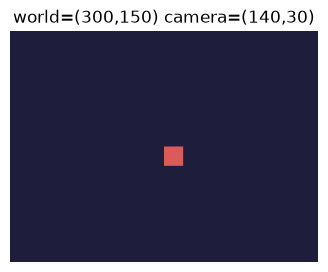

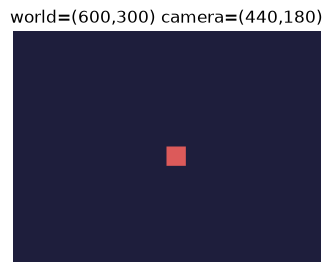

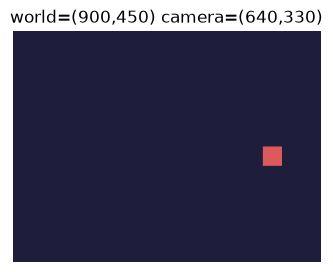

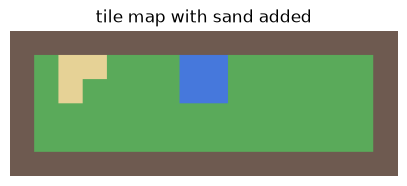

In [10]:
# sample solution 1 - a sprite bouncing off all 4 edges
class BouncingSprite(pygame.sprite.Sprite):
    def __init__(self, x, y):
        super().__init__()
        self.image = pygame.Surface((16, 16))
        self.image.fill((240, 120, 200))
        self.rect = self.image.get_rect()
        self.rect.x = x
        self.rect.y = y
        self.velocity_x = 4
        self.velocity_y = 3

    def update(self):
        self.rect.x += self.velocity_x
        self.rect.y += self.velocity_y
        if self.rect.left <= 0 or self.rect.right >= SCREEN_WIDTH:
            self.velocity_x *= -1  # reverse horizontal direction whenever we touch the left/right edge
        if self.rect.top <= 0 or self.rect.bottom >= SCREEN_HEIGHT:
            self.velocity_y *= -1  # reverse vertical direction whenever we touch the top/bottom edge

bouncer_group = pygame.sprite.Group(BouncingSprite(10, 10))
bounce_snapshots = []
for frame_number in range(80):  # enough frames for at least one bounce off an edge to happen
    bouncer_group.update()
    screen.fill((25, 25, 40))
    bouncer_group.draw(screen)
    if frame_number % 20 == 0:
        bounce_snapshots.append(pygame.surfarray.array3d(screen).swapaxes(0, 1).copy())

fig, axes = plt.subplots(1, len(bounce_snapshots), figsize=(2.2 * len(bounce_snapshots), 2.2))
for ax, pixels in zip(axes, bounce_snapshots):
    ax.imshow(pixels)
    ax.axis("off")
plt.tight_layout()
plt.show()


# sample solution 2 - a 3-frame walk cycle
class ThreeFrameBlobSprite(pygame.sprite.Sprite):
    def __init__(self, x, y):
        super().__init__()
        self.frames = self._build_frames()
        self.frame_index = 0
        self.ticks_since_last_frame = 0
        self.image = self.frames[0]
        self.rect = self.image.get_rect()
        self.rect.x = x
        self.rect.y = y

    def _build_frames(self):
        frame_a = pygame.Surface((32, 32), pygame.SRCALPHA)
        pygame.draw.circle(frame_a, (240, 200, 60), (16, 20), 12)
        frame_b = pygame.Surface((32, 32), pygame.SRCALPHA)
        pygame.draw.circle(frame_b, (240, 200, 60), (16, 14), 12)
        frame_c = pygame.Surface((32, 32), pygame.SRCALPHA)  # our new 3rd pose
        pygame.draw.circle(frame_c, (240, 200, 60), (16, 20), 15)  # a bit bigger - a visibly distinct 3rd step
        return [frame_a, frame_b, frame_c]

    def update(self):
        self.ticks_since_last_frame += 1
        if self.ticks_since_last_frame >= 6:
            self.ticks_since_last_frame = 0
            self.frame_index = (self.frame_index + 1) % len(self.frames)  # now wraps around all 3 frames
            self.image = self.frames[self.frame_index]

three_frame_group = pygame.sprite.Group(ThreeFrameBlobSprite(140, 100))
three_frame_snapshots = []
for frame_number in range(20):
    three_frame_group.update()
    screen.fill((30, 30, 60))
    three_frame_group.draw(screen)
    if frame_number % 6 == 0 or frame_number == 19:
        three_frame_snapshots.append((frame_number, pygame.surfarray.array3d(screen).swapaxes(0, 1).copy()))

fig, axes = plt.subplots(1, len(three_frame_snapshots), figsize=(2.2 * len(three_frame_snapshots), 2.2))
for ax, (frame_number, pixels) in zip(axes, three_frame_snapshots):
    ax.imshow(pixels)
    ax.set_title(f"frame {frame_number}")
    ax.axis("off")
plt.tight_layout()
plt.show()


# sample solution 3 - a camera clamped both horizontally AND vertically
solution_world_width = 960
solution_world_height = 600  # now taller than the screen too, so vertical clamping actually matters

solution_player = ColorBlockSprite(0, 0, 20, (220, 90, 90))
for step in range(3):
    solution_player.rect.x += 300
    solution_player.rect.y += 150
    cam_x = max(0, min(solution_player.rect.x - SCREEN_WIDTH // 2, solution_world_width - SCREEN_WIDTH))
    cam_y = max(0, min(solution_player.rect.y - SCREEN_HEIGHT // 2, solution_world_height - SCREEN_HEIGHT))
    screen.fill((30, 30, 60))
    screen.blit(solution_player.image, (solution_player.rect.x - cam_x, solution_player.rect.y - cam_y))
    show_surface(screen, title=f"world=({solution_player.rect.x},{solution_player.rect.y}) camera=({cam_x},{cam_y})")


# sample solution 4 - adding a "sand" tile type
tile_map_with_sand = [row[:] for row in tile_map]  # copy the map so we don't mutate the original from above
tile_colors_with_sand = dict(TILE_COLORS)  # copy the color dict too, same reason
tile_colors_with_sand[3] = (230, 210, 150)  # 3 = sand, a light sandy color

# place a few sand tiles somewhere on the map
tile_map_with_sand[1][2] = 3
tile_map_with_sand[1][3] = 3
tile_map_with_sand[2][2] = 3

sand_map_surface = pygame.Surface((map_width_px, map_height_px))
draw_tile_map(sand_map_surface, tile_map_with_sand, tile_colors_with_sand)  # reuse our renderer from earlier
show_surface(sand_map_surface, title="tile map with sand added", figsize=(5, 2.5))

* congratulation you finished this lesson

## what we learned
* `pygame.sprite.Sprite` as a reusable base class - every sprite needs a `self.image` and a `self.rect`, and we override `update()` for per-frame behaviour
* `pygame.sprite.Group` - `.add()`, `len()`, `.update()` (calls every sprite's own `update()`) and `.draw(surface)` (draws every sprite at once), so our game loop stays tiny no matter how many sprites we have
* simple frame animation: storing a few hand-drawn "poses" in a list and swapping `self.image` between them every few ticks inside `update()`
* velocity-based movement with a bit of "physics-lite": constant horizontal speed, gravity accumulating into `velocity_y` every frame, a jump setting `velocity_y` negative once, and landing resetting it back to 0
* a scrolling camera: tracking a `camera_offset_x`, drawing everything at `rect.x - camera_offset_x` instead of its raw position, and clamping the offset so it never scrolls past the world's edges
* tile-based maps: a 2D list of tile ids + an id-to-color (or id-to-image) lookup dict + a nested-loop renderer - the exact foundation the upcoming RPG lessons build their game world out of